# Warm Restart Evaluation

Evaluate a diffusion model snapshot as initial condition for the gyrokinetic solver. Measures time-to-repair of spectra, fluxes, and distribution function after warm restart from a noisy model prediction.

In [80]:
%load_ext autoreload
%autoreload 2

import sys, os

sys.path.append("..")
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from gyaradax import gk_from_gkw_dir
from gyaradax.solver import GKState, gkstep_single, mode_amplitude
from gyaradax.simulate import _compute_phi_for_init
from gyaradax.plot_utils import plot_nd
from gyaradax.integrals import get_integrals
from gyaradax.diag import get_diagnostics

## Configuration

In [ ]:
ITERATION = 13
GKW_DIR = f"/restricteddata/ukaea/gyrokinetics/raw/iteration_{ITERATION}"
N_EVAL_STEPS = 1000
MIXED_PRECISION = True

df_gt, geometry, params, state_init, pre = gk_from_gkw_dir(GKW_DIR, mixed_precision=MIXED_PRECISION)

kx, ky = np.asarray(geometry["kxrh"]), np.asarray(geometry["krho"])
nkx, nky = len(kx), len(ky)
t_start = float(state_init.time)
print(f"iteration_{ITERATION}: {df_gt.shape}, dt={params.dt}, t={t_start:.2f}")

## 1. Model-space transforms

In [84]:
def to_model_space(df_spectral):
    df_np = np.fft.ifftshift(np.array(df_spectral), axes=(3,))
    df_real = np.fft.ifftn(df_np, axes=(3, 4), norm="forward")
    return np.stack([df_real.real, df_real.imag]).astype(np.float32)


def from_model_space(df_f32_2ch):
    df_complex = (df_f32_2ch[0] + 1j * df_f32_2ch[1]).astype(np.complex128)
    df_spectral = np.fft.fftn(df_complex, axes=(3, 4), norm="forward")
    return jnp.asarray(np.fft.fftshift(df_spectral, axes=(3,)), dtype=jnp.complex128)


df_rt = from_model_space(to_model_space(df_gt))
print(f"roundtrip error: {float(jnp.linalg.norm(df_rt - df_gt) / jnp.linalg.norm(df_gt)):.2e}")

roundtrip error: 2.53e-08


## 2. Diffusion model prediction

Replace this cell with the actual model. The model receives and produces data in **model space**: `float32`, shape `(2, nvpar, nmu, ns, nx, ny)`, where channel 0 = real part, channel 1 = imaginary part, and the last two axes are **real-space** (x, y).

The output variable must be `DF_PRED` — a float32 array in model space. Everything downstream depends only on `DF_PRED`.

In [85]:
DF_GT_MODEL = to_model_space(df_gt)

rng = np.random.default_rng(seed=42)
channel_std = np.std(DF_GT_MODEL, axis=(2, 3, 4, 5), keepdims=True)
DF_PRED = (rng.normal(size=DF_GT_MODEL.shape) * channel_std).astype(np.float32)

print(
    f"DF_PRED: {DF_PRED.shape} {DF_PRED.dtype}, rel. error: {np.linalg.norm(DF_PRED - DF_GT_MODEL) / np.linalg.norm(DF_GT_MODEL):.2f}"
)

DF_PRED: (2, 32, 8, 16, 85, 32) float32, rel. error: 1.41


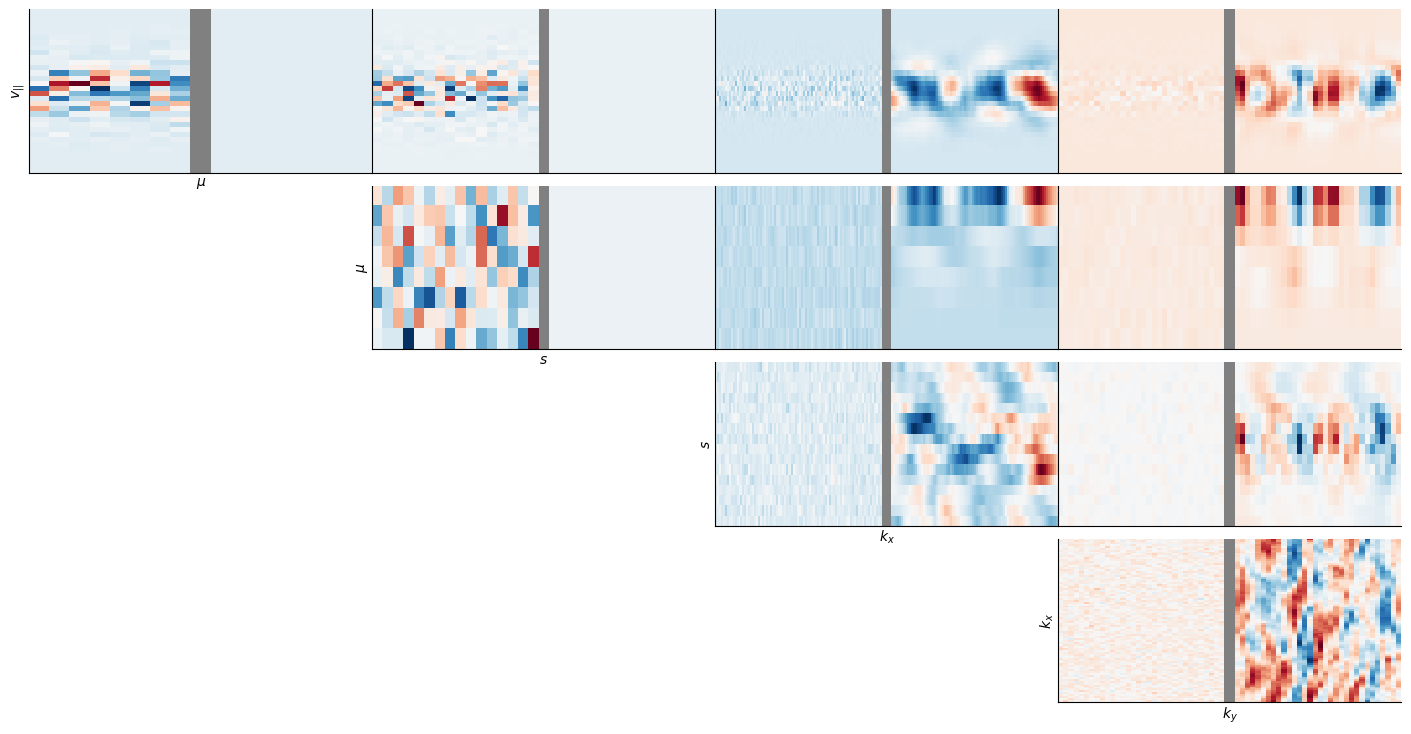

In [86]:
_ = plot_nd(DF_PRED, DF_GT_MODEL)

## 3. Transform prediction to solver space

`DF_PRED` (float32 real-space) -> `df_warm` (complex128 spectral). Everything below uses only `df_warm` and `df_gt`.

In [87]:
df_warm = from_model_space(DF_PRED)

spectral_err = float(jnp.linalg.norm(df_warm - df_gt) / jnp.linalg.norm(df_gt))
print(f"df_warm: {df_warm.shape} {df_warm.dtype}")
print(f"spectral-space rel. error vs GT: {spectral_err:.4f} ({spectral_err*100:.2f}%)")

df_warm: (32, 8, 16, 85, 32) complex128
spectral-space rel. error vs GT: 1.4139 (141.39%)


## 4. Step-by-step simulation

In [ ]:
def make_state(df):
    phi0 = _compute_phi_for_init(df, geometry, params)
    amp0 = mode_amplitude(phi0, geometry, params.norm_eps)
    return GKState(
        time=jnp.array(t_start, dtype=jnp.float64),
        step=jnp.array(0, dtype=jnp.int32),
        accumulated_norm_factor=jnp.ones(nky, dtype=jnp.float64),
        window_start_amp=amp0,
        last_growth_rate=jnp.zeros(nky, dtype=jnp.float64),
    )


def run_trajectory(df_init, label, n_steps=N_EVAL_STEPS):
    df, state = df_init, make_state(df_init)
    log = {"time": [], "kx_spec": [], "ky_spec": [], "pflux": [], "eflux": [], "vflux": []}

    phi, fluxes = get_integrals(
        df, geometry, params=params, pre=pre, adiabatic_electrons=params.adiabatic_electrons
    )
    diags = get_diagnostics(phi, fluxes, state)
    for k in log:
        log[k].append(np.array(diags[k]))

    for i in range(n_steps):
        df, (phi, _), state = gkstep_single(df, geometry, params, state, pre)
        phi, fluxes = get_integrals(
            df, geometry, params=params, pre=pre, adiabatic_electrons=params.adiabatic_electrons
        )
        diags = get_diagnostics(phi, fluxes, state)
        for k in log:
            log[k].append(np.array(diags[k]))
        if (i + 1) % 50 == 0 or i == 0:
            print(
                f"  [{label}] {i+1:>4d}/{n_steps}  t={float(state.time):.3f}  Q={float(diags['eflux']):.4e}"
            )

    return {k: np.array(v) for k, v in log.items()}


print(f"{N_EVAL_STEPS} steps, dt={params.dt}\n")
log_gt = run_trajectory(df_gt, "GT")
print()
log_warm = run_trajectory(df_warm, "WARM")

## 5. Spectra and flux comparison

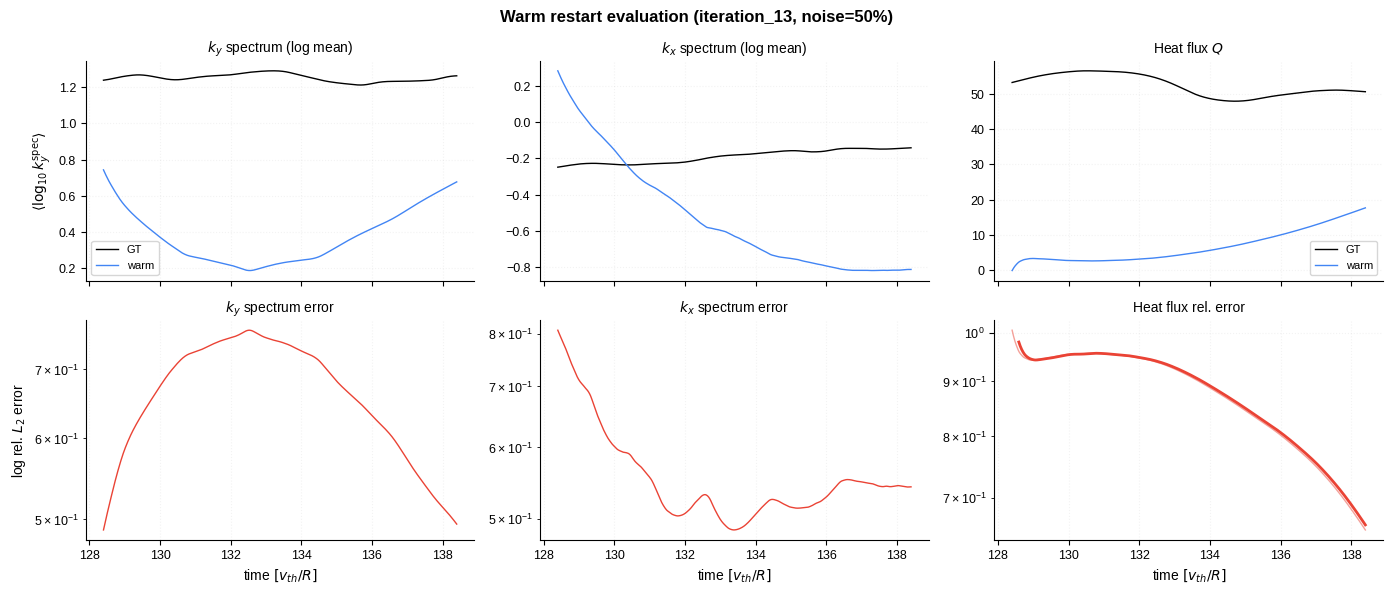

In [89]:
from gyaradax.plot_utils import JAX_COLORS

steps = np.arange(len(log_gt["time"]))
time_axis = log_gt["time"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)

# --- Row 1: absolute values ---
# ky spectrum (log-space mean over ky modes)
gt_ky = np.mean(np.log10(np.maximum(log_gt["ky_spec"], 1e-30)), axis=1)
warm_ky = np.mean(np.log10(np.maximum(log_warm["ky_spec"], 1e-30)), axis=1)
axes[0, 0].plot(time_axis, gt_ky, color="k", lw=1, label="GT")
axes[0, 0].plot(time_axis, warm_ky, color=JAX_COLORS["blue"], lw=1, label="warm")
axes[0, 0].set_ylabel(r"$\langle \log_{10} k_y^{\mathrm{spec}} \rangle$")
axes[0, 0].set_title(r"$k_y$ spectrum (log mean)")
axes[0, 0].legend(fontsize=8)

# kx spectrum
gt_kx = np.mean(np.log10(np.maximum(log_gt["kx_spec"], 1e-30)), axis=1)
warm_kx = np.mean(np.log10(np.maximum(log_warm["kx_spec"], 1e-30)), axis=1)
axes[0, 1].plot(time_axis, gt_kx, color="k", lw=1)
axes[0, 1].plot(time_axis, warm_kx, color=JAX_COLORS["blue"], lw=1)
axes[0, 1].set_title(r"$k_x$ spectrum (log mean)")

# heat flux
axes[0, 2].plot(time_axis, log_gt["eflux"], color="k", lw=1, label="GT")
axes[0, 2].plot(time_axis, log_warm["eflux"], color=JAX_COLORS["blue"], lw=1, label="warm")
axes[0, 2].set_title("Heat flux $Q$")
axes[0, 2].legend(fontsize=8)

# --- Row 2: errors (warm - GT) ---
# log-space ky spectrum error per step
ky_log_err = np.array(
    [
        np.linalg.norm(
            np.log10(np.maximum(log_warm["ky_spec"][i], 1e-30))
            - np.log10(np.maximum(log_gt["ky_spec"][i], 1e-30))
        )
        / max(np.linalg.norm(np.log10(np.maximum(log_gt["ky_spec"][i], 1e-30))), 1e-30)
        for i in range(len(steps))
    ]
)
axes[1, 0].semilogy(time_axis, ky_log_err, color=JAX_COLORS["red"], lw=1)
axes[1, 0].set_ylabel("log rel. $L_2$ error")
axes[1, 0].set_xlabel(r"time $[v_{th}/R]$")
axes[1, 0].set_title(r"$k_y$ spectrum error")

# kx spectrum error
kx_log_err = np.array(
    [
        np.linalg.norm(
            np.log10(np.maximum(log_warm["kx_spec"][i], 1e-30))
            - np.log10(np.maximum(log_gt["kx_spec"][i], 1e-30))
        )
        / max(np.linalg.norm(np.log10(np.maximum(log_gt["kx_spec"][i], 1e-30))), 1e-30)
        for i in range(len(steps))
    ]
)
axes[1, 1].semilogy(time_axis, kx_log_err, color=JAX_COLORS["red"], lw=1)
axes[1, 1].set_xlabel(r"time $[v_{th}/R]$")
axes[1, 1].set_title(r"$k_x$ spectrum error")

# flux error (relative)
eflux_err = np.abs(log_warm["eflux"] - log_gt["eflux"]) / np.maximum(np.abs(log_gt["eflux"]), 1e-30)
axes[1, 2].semilogy(time_axis, eflux_err, color=JAX_COLORS["red"], lw=1, alpha=0.5)
# smoothed
win = min(20, len(eflux_err) // 4)
if win > 1:
    eflux_smooth = np.convolve(eflux_err, np.ones(win) / win, mode="valid")
    axes[1, 2].semilogy(time_axis[win - 1 :], eflux_smooth, color=JAX_COLORS["red"], lw=2)
axes[1, 2].set_xlabel(r"time $[v_{th}/R]$")
axes[1, 2].set_title("Heat flux rel. error")

for ax in axes.flat:
    ax.grid(True, alpha=0.15)

fig.suptitle(
    f"Warm restart evaluation (iteration_{ITERATION}, noise={NOISE_LEVEL*100:.0f}%)",
    fontweight="bold",
)
fig.tight_layout()
plt.show()

## 6. Time-to-repair metrics

In [90]:
def time_to_repair(error_ts, threshold, time_axis, run_len=10):
    below = error_ts < threshold
    for i in range(len(below) - run_len):
        if np.all(below[i : i + run_len]):
            return float(time_axis[i] - time_axis[0])
    return np.inf


ky_ttr_01 = time_to_repair(ky_log_err, 0.01, time_axis)
ky_ttr_05 = time_to_repair(ky_log_err, 0.05, time_axis)
flux_ttr_10 = time_to_repair(
    eflux_smooth if win > 1 else eflux_err, 0.10, time_axis[win - 1 :] if win > 1 else time_axis
)
flux_ttr_50 = time_to_repair(
    eflux_smooth if win > 1 else eflux_err, 0.50, time_axis[win - 1 :] if win > 1 else time_axis
)

gt_mean = np.mean(log_gt["eflux"][-N_EVAL_STEPS // 4 :])
gt_std = np.std(log_gt["eflux"][-N_EVAL_STEPS // 4 :])
in_band = np.abs(log_warm["eflux"] - gt_mean) < 2 * gt_std
crossing_idx = np.argmax(in_band) if np.any(in_band) else len(in_band)
crossing_time = (
    float(time_axis[crossing_idx] - time_axis[0]) if crossing_idx < len(in_band) else np.inf
)

print(f"TTR (noise={NOISE_LEVEL*100:.0f}%)")
print(f"  ky spec  1%: {ky_ttr_01:.3f}   5%: {ky_ttr_05:.3f}  [v_th/R]")
print(f"  Q flux  10%: {flux_ttr_10:.3f}  50%: {flux_ttr_50:.3f}  [v_th/R]")
print(f"  crossing:    {crossing_time:.3f}  [v_th/R]")
print(f"  total time:  {float(time_axis[-1] - time_axis[0]):.3f}  [v_th/R]")

TTR (noise=50%)
  ky spec  1%: inf   5%: inf  [v_th/R]
  Q flux  10%: inf  50%: inf  [v_th/R]
  crossing:    inf  [v_th/R]
  total time:  10.000  [v_th/R]


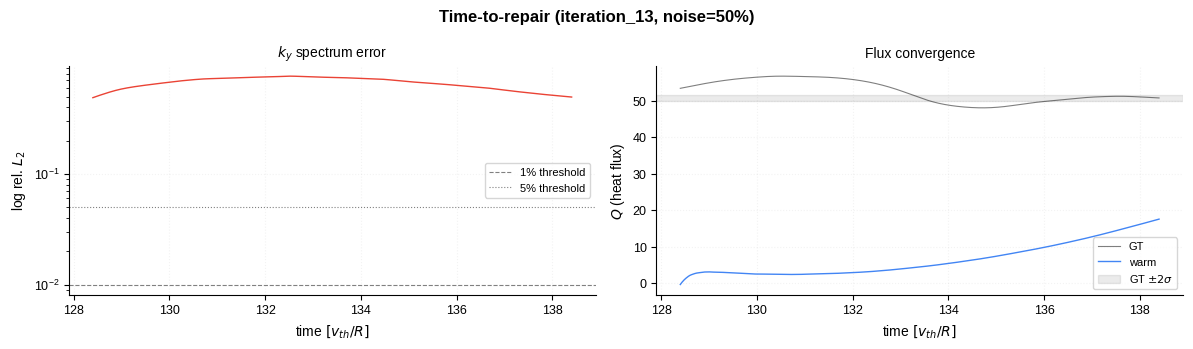

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

# ky spectrum error with TTR markers
ax1.semilogy(time_axis, ky_log_err, color=JAX_COLORS["red"], lw=1)
ax1.axhline(0.01, color="gray", ls="--", lw=0.8, label="1% threshold")
ax1.axhline(0.05, color="gray", ls=":", lw=0.8, label="5% threshold")
if ky_ttr_01 < np.inf:
    ax1.axvline(
        time_axis[0] + ky_ttr_01,
        color=JAX_COLORS["green"],
        ls="-",
        lw=1.5,
        label=f"TTR(1%)={ky_ttr_01:.2f}",
    )
if ky_ttr_05 < np.inf:
    ax1.axvline(
        time_axis[0] + ky_ttr_05,
        color=JAX_COLORS["blue"],
        ls="-",
        lw=1.5,
        label=f"TTR(5%)={ky_ttr_05:.2f}",
    )
ax1.set_xlabel(r"time $[v_{th}/R]$")
ax1.set_ylabel("log rel. $L_2$")
ax1.set_title(r"$k_y$ spectrum error")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.15)

# heat flux with GT band
ax2.plot(time_axis, log_gt["eflux"], color="k", lw=0.8, alpha=0.5, label="GT")
ax2.plot(time_axis, log_warm["eflux"], color=JAX_COLORS["blue"], lw=1, label="warm")
ax2.axhspan(
    gt_mean - 2 * gt_std, gt_mean + 2 * gt_std, color="k", alpha=0.08, label=r"GT $\pm 2\sigma$"
)
if crossing_time < np.inf:
    ax2.axvline(
        time_axis[0] + crossing_time,
        color=JAX_COLORS["green"],
        ls="-",
        lw=1.5,
        label=f"crossing={crossing_time:.2f}",
    )
ax2.set_xlabel(r"time $[v_{th}/R]$")
ax2.set_ylabel("$Q$ (heat flux)")
ax2.set_title("Flux convergence")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.15)

fig.suptitle(
    f"Time-to-repair (iteration_{ITERATION}, noise={NOISE_LEVEL*100:.0f}%)", fontweight="bold"
)
fig.tight_layout()
plt.show()